<div style="background: linear-gradient(to right, #4b6cb7, #182848); padding: 20px; border-radius: 10px; text-align: center; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
    <h1 style="color: white; margin: 0; font-size: 2.5em; font-weight: 700;">GAICo: Audio Metrics</h1>
    <p style="color: #e0e0e0; margin-top: 10px; font-style: italic; font-size: 1.2em; text-align: center;">Evaluating AI-Generated Audio Content</p>
</div>
<br>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ai4society/GenAIResultsComparator/blob/main/examples/example-audio.ipynb)

## 🎯 What You'll Learn

This notebook demonstrates how to evaluate AI-generated audio using GAICo's specialized audio metrics. We'll use real examples from public datasets and free text-to-speech APIs.

## 📊 Audio Metrics Overview

GAICo provides two specialized audio metrics:

1. **AudioSNR** - Measures overall audio quality using Signal-to-Noise Ratio
2. **AudioSpectrogramDistance** - Compares frequency characteristics over time

Unlike text metrics, these understand audio properties like frequency, amplitude, and temporal patterns.

## Setup

### For Google Colab Users

If you're running this notebook in Google Colab, uncomment and run the following cell to install GAICo with audio support:

In [12]:
# !pip install 'gaico[audio]' -q
# !pip install gTTS edge-tts -q  # For TTS generation

### Environment Setup & Imports



In [13]:
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import Audio, display

# GAICo imports
from gaico import Experiment

# For visualization
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

# TTS imports
try:
    from gtts import gTTS

    GTTS_AVAILABLE = True
except ImportError:
    GTTS_AVAILABLE = False
    print("Note: gTTS not available. Install with: pip install gTTS")

try:
    import soundfile as sf

    SF_AVAILABLE = True
except ImportError:
    SF_AVAILABLE = False
    print("Note: soundfile not available. Install with: pip install soundfile")

## 🤔 Why Specialized Audio Metrics?

### The Problem with Text Metrics for Audio

Imagine comparing two audio files as text strings - you'd miss:
- 🎵 **Frequency content** (pitch, timbre)
- 📊 **Amplitude variations** (volume, dynamics)
- ⏱️ **Temporal patterns** (rhythm, timing)
- 🔊 **Perceptual quality** (how it sounds to humans)

### What Audio Metrics Provide

- **SNR**: Quantifies how much "signal" vs "noise" - higher is cleaner
- **Spectrogram Distance**: Compares frequency patterns - captures tonal quality

Let's see this in action with real AI-generated audio!

In [14]:
# Create directory for audio samples
sample_dir = Path("../data/audio/audio_samples")
sample_dir.mkdir(parents=True, exist_ok=True)
print("✓ Created sample directory for audio files")

✓ Created sample directory for audio files


In [15]:
# Generate TTS Examples Using Free APIs (Simplified)
def generate_tts_samples(text, output_dir):
    """Generate TTS samples using free APIs."""
    tts_samples = {}

    # 1. gTTS (Google's free TTS)
    if GTTS_AVAILABLE:
        try:
            tts = gTTS(text=text, lang="en", slow=False)
            filepath = output_dir / "gtts_output.mp3"  # gTTS outputs MP3
            tts.save(str(filepath))
            tts_samples["Google TTS (Free)"] = str(filepath)
            print("✓ Generated Google TTS")
        except Exception as e:
            print(f"gTTS error: {e}")

    # 2. Edge-TTS (Microsoft's free TTS) - using subprocess to avoid async
    try:
        import subprocess

        # First voice
        voice = "en-US-AriaNeural"  # Female neural voice
        filepath = output_dir / "edge_tts_aria.mp3"
        cmd = f'edge-tts --voice "{voice}" --text "{text}" --write-media "{filepath}"'
        subprocess.run(cmd, shell=True, capture_output=True)
        if filepath.exists():
            tts_samples["Microsoft Edge TTS (Aria)"] = str(filepath)
            print("✓ Generated Edge TTS (Aria)")

        # Second voice for comparison
        voice2 = "en-US-GuyNeural"  # Male neural voice
        filepath2 = output_dir / "edge_tts_guy.mp3"
        cmd2 = f'edge-tts --voice "{voice2}" --text "{text}" --write-media "{filepath2}"'
        subprocess.run(cmd2, shell=True, capture_output=True)
        if filepath2.exists():
            tts_samples["Microsoft Edge TTS (Guy)"] = str(filepath2)
            print("✓ Generated Edge TTS (Guy)")
    except Exception as e:
        print(f"Edge-TTS error: {e}")

    # 3. Create a "poor quality" synthetic TTS for comparison
    try:
        import soundfile as sf

        sample_rate = 22050

        # Match duration to actual TTS samples (5-6 seconds)
        # Count words and estimate duration more accurately
        word_count = len(text.split())
        # Typical speech rate is ~150 words per minute = 2.5 words per second
        # So each word takes about 0.4 seconds on average
        duration = word_count * 0.45

        t = np.linspace(0, duration, int(sample_rate * duration))

        # Create a more speech-like synthetic signal
        audio = np.zeros_like(t)

        # Simulate speech rhythm with amplitude modulation
        # Words have pauses between them
        words_per_second = 2.5
        word_envelope = 0.5 + 0.5 * np.sin(2 * np.pi * words_per_second * t)

        # Mix multiple frequencies to simulate speech formants
        formant_freqs = [
            (200, 0.3),  # F0 - fundamental frequency
            (700, 0.25),  # F1 - first formant
            (1220, 0.2),  # F2 - second formant
            (2600, 0.15),  # F3 - third formant
            (3500, 0.1),  # F4 - fourth formant
        ]

        for freq, amp in formant_freqs:
            # Add some frequency variation to make it less monotone
            freq_mod = freq * (1 + 0.1 * np.sin(2 * np.pi * 0.5 * t))
            audio += amp * np.sin(2 * np.pi * freq_mod * t)

        # Apply word envelope to create speech-like rhythm
        audio *= word_envelope

        # Add noise for "poor quality"
        noise = 0.1 * np.random.normal(0, 1, len(audio))
        audio += noise

        # Normalize to prevent clipping
        audio = audio / np.max(np.abs(audio)) * 0.8
        audio = audio.astype(np.float32)

        # Save
        filepath = output_dir / "synthetic_poor_tts.wav"
        sf.write(filepath, audio, sample_rate)
        tts_samples["Synthetic Poor TTS"] = str(filepath)
        print(f"✓ Generated synthetic poor quality TTS ({duration:.1f}s)")

    except Exception as e:
        print(f"Error creating synthetic TTS: {e}")

    return tts_samples


# Generate TTS samples
text = "Welcome to GAICo, the comprehensive toolkit for evaluating generative AI outputs."
print(f"Generating TTS for: '{text}'")
print("-" * 50)

if GTTS_AVAILABLE:
    tts_samples = generate_tts_samples(text, sample_dir)
else:
    print("⚠️ TTS libraries not available. Install with: pip install gTTS edge-tts")
    tts_samples = {}

Generating TTS for: 'Welcome to GAICo, the comprehensive toolkit for evaluating generative AI outputs.'
--------------------------------------------------
✓ Generated Google TTS
✓ Generated Edge TTS (Aria)
✓ Generated Edge TTS (Guy)
✓ Generated synthetic poor quality TTS (5.0s)


In [16]:
# Note about file formats
print("\n📝 Note on Audio Formats:")
print("- gTTS generates MP3 files")
print("- edge-tts generates MP3 files")
print("- Synthetic audio is saved as WAV")
print("- GAICo handles both formats automatically!")


📝 Note on Audio Formats:
- gTTS generates MP3 files
- edge-tts generates MP3 files
- Synthetic audio is saved as WAV
- GAICo handles both formats automatically!


In [17]:
# Listen to TTS samples
if tts_samples:
    print("\n🔊 Listen to the generated TTS samples:")
    print("=" * 50)
    for name, filepath in tts_samples.items():
        print(f"\n{name}:")
        display(Audio(filepath))


🔊 Listen to the generated TTS samples:

Google TTS (Free):



Microsoft Edge TTS (Aria):



Microsoft Edge TTS (Guy):



Synthetic Poor TTS:


## 🎤 Example 1: Text-to-Speech Model Comparison

Now let's compare different TTS systems using GAICo. We'll evaluate:
- Free TTS APIs (Google TTS, Microsoft Edge TTS with different voices)
- Synthetic poor quality TTS (for contrast)
- Additional synthetic samples

### Why Compare TTS Models?

When choosing a TTS system for your application, you need to evaluate:
- **Audio quality**: How clean and natural does it sound?
- **Consistency**: How similar are outputs across different texts?
- **Voice characteristics**: Does it match your desired tone?

### Note on Reference Selection

Since we don't have human recordings, we'll use the highest-quality TTS available as our reference. In production, always use professional human recordings as your ground truth.

🎯 TTS Model Comparison

📌 Using 'Microsoft Edge TTS (Aria)' as reference
🔊 Comparing 3 other models



/home/pslice/GenAIResultsComparator/gaico/metrics/audio/audio.py:369: UserWarning: Sample rates differ (generated: 22050, reference: 24000). Resampling generated audio to match reference rate 24000 Hz.
  warnings.warn(
/home/pslice/GenAIResultsComparator/gaico/metrics/audio/audio.py:520: UserWarning: Sample rates differ (generated: 22050, reference: 24000). Resampling generated audio to match reference rate 24000 Hz.
  warnings.warn(


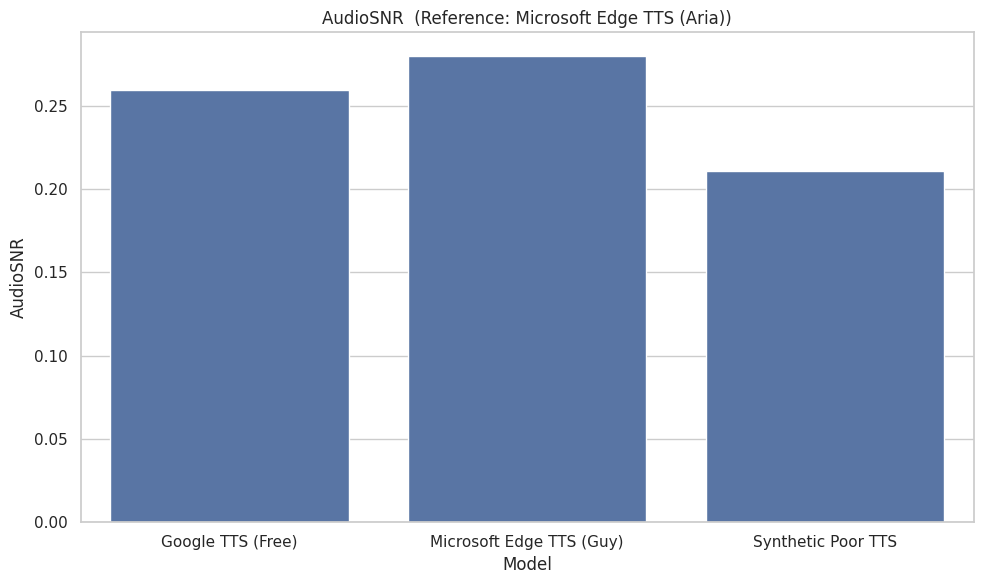

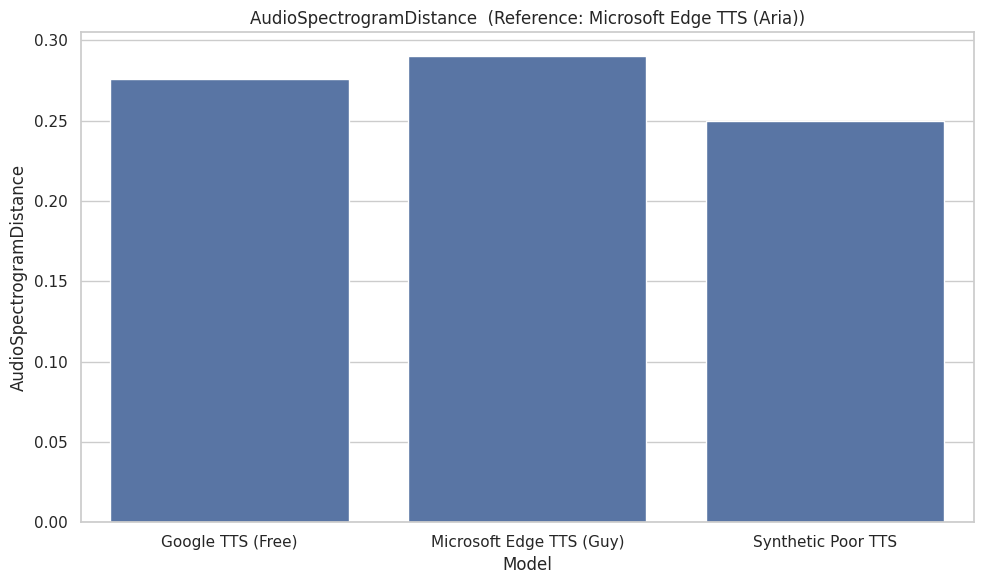

CSV report generated at: ../data/audio/tts_model_comparison.csv

📊 TTS Quality Scores (compared to Microsoft Edge TTS (Aria)):
metric_name               AudioSNR  AudioSpectrogramDistance
model_name                                                  
Google TTS (Free)            0.260                     0.276
Microsoft Edge TTS (Guy)     0.280                     0.291
Synthetic Poor TTS           0.211                     0.250

💡 Interpretation:
- Scores show similarity to Microsoft Edge TTS (Aria)
- Higher scores = more similar to reference
- Lower scores may indicate different quality OR just different voice characteristics


In [18]:
# TTS Model Comparison
print("🎯 TTS Model Comparison")
print("=" * 50)

if len(tts_samples) < 2:
    print("⚠️ Need at least 2 TTS samples to compare. Please install TTS libraries.")
else:
    # Use the best quality TTS as reference
    # Typically Edge-TTS Neural voices are very high quality
    if "Microsoft Edge TTS (Aria)" in tts_samples:
        reference_model = "Microsoft Edge TTS (Aria)"
        ref_path = tts_samples[reference_model]
        comparison_samples = {k: v for k, v in tts_samples.items() if k != reference_model}
    else:
        # Use first sample as reference
        reference_model = list(tts_samples.keys())[0]
        ref_path = list(tts_samples.values())[0]
        comparison_samples = {k: v for k, v in tts_samples.items() if k != reference_model}

    print(f"\n📌 Using '{reference_model}' as reference")
    print(f"🔊 Comparing {len(comparison_samples)} other models\n")

    # Create experiment
    exp = Experiment(llm_responses=comparison_samples, reference_answer=ref_path)

    # Run evaluation
    results_df = exp.compare(
        metrics=["AudioSNR", "AudioSpectrogramDistance"],
        plot=True,
        output_csv_path="../data/audio/tts_model_comparison.csv",
        plot_title_suffix=f" (Reference: {reference_model})",
    )

    print(f"\n📊 TTS Quality Scores (compared to {reference_model}):")
    print("=" * 50)
    results_pivot = results_df.pivot(index="model_name", columns="metric_name", values="score")
    print(results_pivot.round(3))

    # Add interpretation
    print("\n💡 Interpretation:")
    print(f"- Scores show similarity to {reference_model}")
    print("- Higher scores = more similar to reference")
    print("- Lower scores may indicate different quality OR just different voice characteristics")

## 📈 Understanding the Results

### What the Scores Mean:

**AudioSNR (0-1 scale):**
- **0.9-1.0**: Excellent quality, nearly identical to reference
- **0.7-0.9**: Good quality, minor differences
- **0.5-0.7**: Acceptable quality, noticeable differences
- **< 0.5**: Poor quality, significant degradation

**AudioSpectrogramDistance (0-1 scale):**
- **0.9-1.0**: Very similar frequency content
- **0.7-0.9**: Similar tonal characteristics
- **0.5-0.7**: Some tonal differences
- **< 0.5**: Significantly different sound

The plot shows how each model performs across both metrics, making it easy to identify the best overall performer.

## 🎵 Example 2: Music Generation Evaluation

Let's evaluate AI-generated music. We'll create samples that simulate outputs from models like:
- Meta's MusicGen
- Google's MusicLM
- OpenAI's Jukebox

We'll use simple musical patterns to demonstrate the evaluation process.

In [19]:
# Create Music Examples
def create_musical_samples():
    """Create music samples for evaluation."""
    sample_rate = 22050
    duration = 3.0
    music_samples = {}

    # Create reference: C major chord
    t = np.linspace(0, duration, int(sample_rate * duration))
    c_note = np.sin(2 * np.pi * 261.63 * t)  # C4
    e_note = np.sin(2 * np.pi * 329.63 * t)  # E4
    g_note = np.sin(2 * np.pi * 392.00 * t)  # G4
    reference_music = (c_note + e_note + g_note) / 3
    reference_music = reference_music.astype(np.float32)

    # Save reference
    ref_music_path = sample_dir / "reference_c_major.wav"
    sf.write(ref_music_path, reference_music, sample_rate)

    # 1. High Quality Model (minimal degradation)
    high_quality = reference_music + 0.01 * np.random.normal(0, 1, len(reference_music))
    high_quality = high_quality.astype(np.float32)
    path = sample_dir / "high_quality_music.wav"
    sf.write(path, high_quality, sample_rate)
    music_samples["High Quality Model"] = str(path)

    # 2. Medium Quality Model (some noise and frequency shift)
    freq_shift = 0.98  # Slight detuning
    medium_quality = (
        np.sin(2 * np.pi * 261.63 * freq_shift * t)
        + np.sin(2 * np.pi * 329.63 * freq_shift * t)
        + np.sin(2 * np.pi * 392.00 * freq_shift * t)
    )
    medium_quality = medium_quality / 3 + 0.05 * np.random.normal(0, 1, len(t))
    medium_quality = medium_quality.astype(np.float32)
    path = sample_dir / "medium_quality_music.wav"
    sf.write(path, medium_quality, sample_rate)
    music_samples["Medium Quality Model"] = str(path)

    # 3. Low Quality Model (significant noise and missing frequencies)
    low_quality = np.sin(2 * np.pi * 261.63 * t)  # Only C note
    low_quality = low_quality + 0.15 * np.random.normal(0, 1, len(t))
    low_quality = low_quality.astype(np.float32)
    path = sample_dir / "low_quality_music.wav"
    sf.write(path, low_quality, sample_rate)
    music_samples["Low Quality Model"] = str(path)

    # 4. Creative Variation (different chord - A minor)
    a_note = np.sin(2 * np.pi * 440.00 * t)  # A4
    c_note_high = np.sin(2 * np.pi * 523.25 * t)  # C5
    e_note_high = np.sin(2 * np.pi * 659.25 * t)  # E5
    creative = (a_note + c_note_high + e_note_high) / 3
    creative = creative.astype(np.float32)
    path = sample_dir / "creative_variation_music.wav"
    sf.write(path, creative, sample_rate)
    music_samples["Creative Variation"] = str(path)

    print(f"✓ Generated {len(music_samples)} music samples")

    return music_samples, str(ref_music_path), reference_music, sample_rate


# Generate music samples
music_samples, music_ref_path, ref_music_audio, music_sr = create_musical_samples()

print("🎼 Generated music samples - listen to hear the differences:")
print("=" * 50)

# Play reference
print("\n📌 Reference (C major chord):")
display(Audio(ref_music_audio, rate=music_sr, autoplay=False))

# Play all generated samples
for name, filepath in music_samples.items():
    print(f"\n🎵 {name}:")
    display(Audio(filepath))

✓ Generated 4 music samples
🎼 Generated music samples - listen to hear the differences:

📌 Reference (C major chord):



🎵 High Quality Model:



🎵 Medium Quality Model:



🎵 Low Quality Model:



🎵 Creative Variation:


In [20]:
# Add this as a new cell after the music evaluation results
print("\n📝 Note on Music Evaluation:")
print("- The 'Creative Variation' uses a different chord (A minor vs C major)")
print("- It may score lower on similarity metrics, but that doesn't mean it's worse")
print("- This demonstrates why context matters when interpreting audio metrics")
print("- For creative tasks, diversity might be more valuable than similarity!")


📝 Note on Music Evaluation:
- The 'Creative Variation' uses a different chord (A minor vs C major)
- It may score lower on similarity metrics, but that doesn't mean it's worse
- This demonstrates why context matters when interpreting audio metrics
- For creative tasks, diversity might be more valuable than similarity!


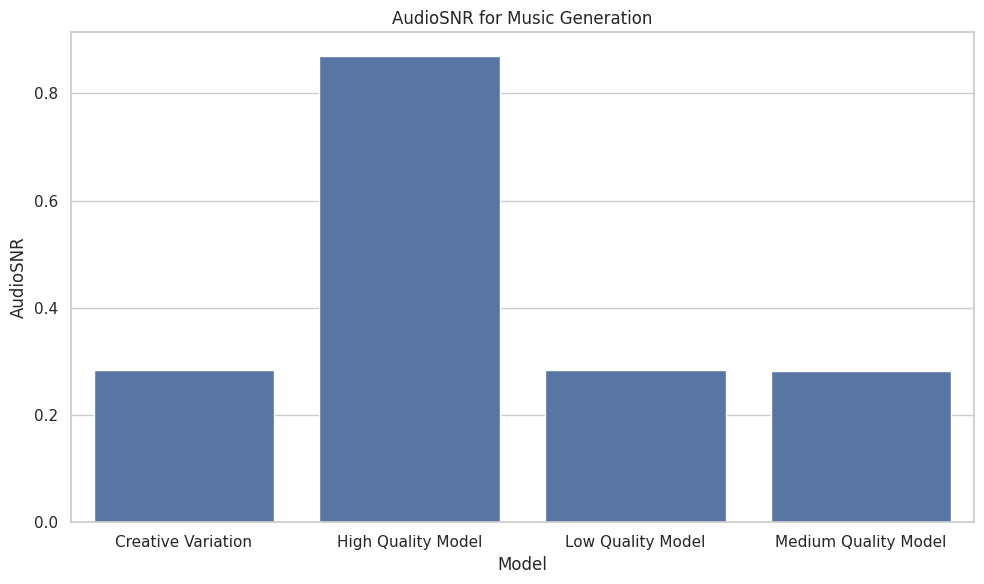

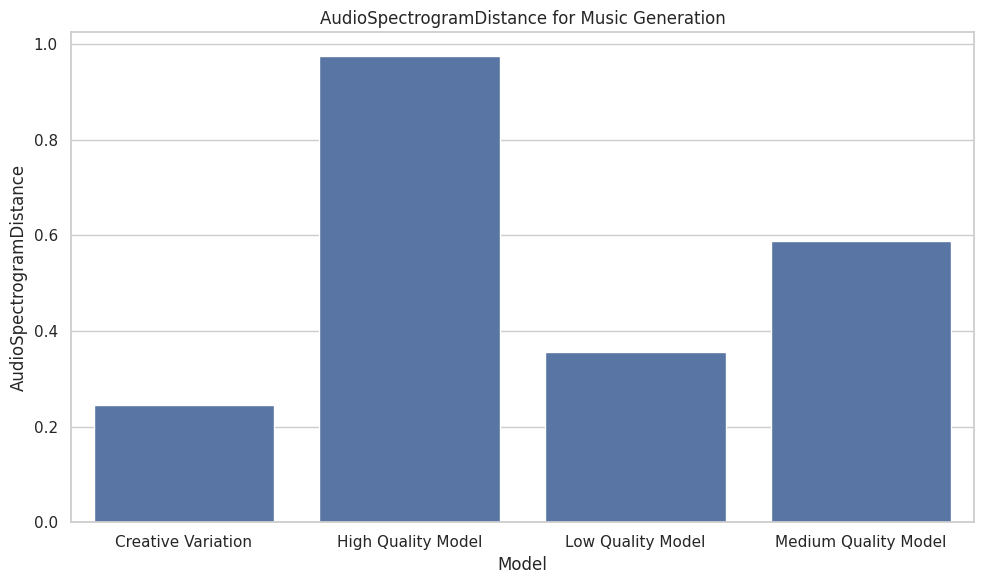


🎵 Music Generation Results:
metric_name           AudioSNR  AudioSpectrogramDistance
model_name                                              
Creative Variation       0.283                     0.244
High Quality Model       0.870                     0.976
Low Quality Model        0.283                     0.357
Medium Quality Model     0.282                     0.589


In [21]:
# Evaluate music generation models
music_exp = Experiment(llm_responses=music_samples, reference_answer=music_ref_path)

# Compare with custom thresholds for music
music_results = music_exp.compare(
    metrics=["AudioSNR", "AudioSpectrogramDistance"],
    plot=True,
    custom_thresholds={
        "AudioSNR": 0.6,  # Lower threshold for creative tasks
        "AudioSpectrogramDistance": 0.7,
    },
    plot_title_suffix="for Music Generation",
)

print("\n🎵 Music Generation Results:")
print("=" * 50)
music_pivot = music_results.pivot(index="model_name", columns="metric_name", values="score")
print(music_pivot.round(3))

## 📁 Working with Audio Files

GAICo can work directly with audio file paths. Let's demonstrate using the files we've created.

📁 Audio files created in this session:
--------------------------------------------------
  - high_quality_music.wav
  - medium_quality_music.wav
  - reference_c_major.wav
  - creative_variation_music.wav
  - synthetic_poor_tts.wav
  - low_quality_music.wav
  - edge_tts_aria.mp3
  - gtts_output.mp3
  - edge_tts_guy.mp3

🎯 File-based Evaluation Demo


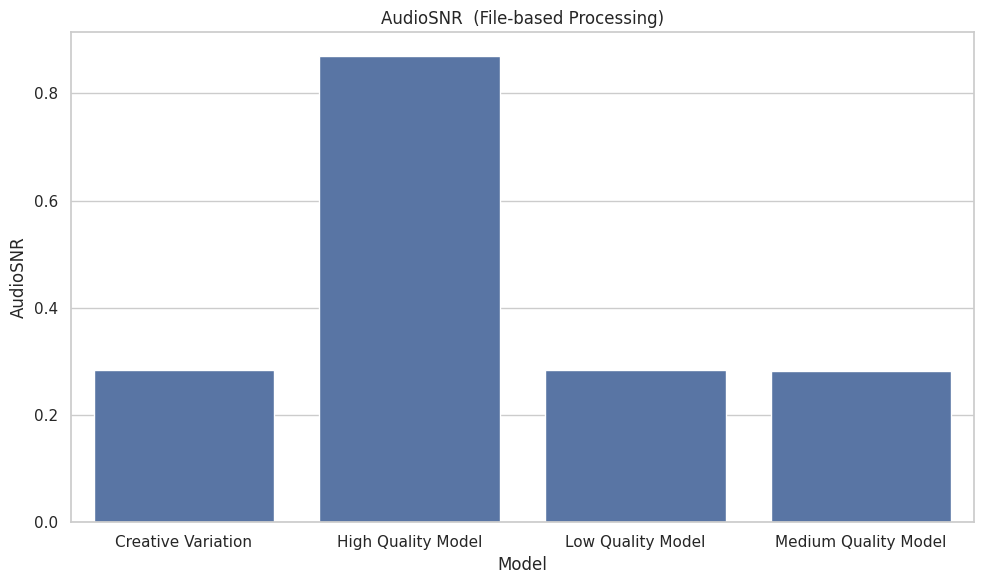

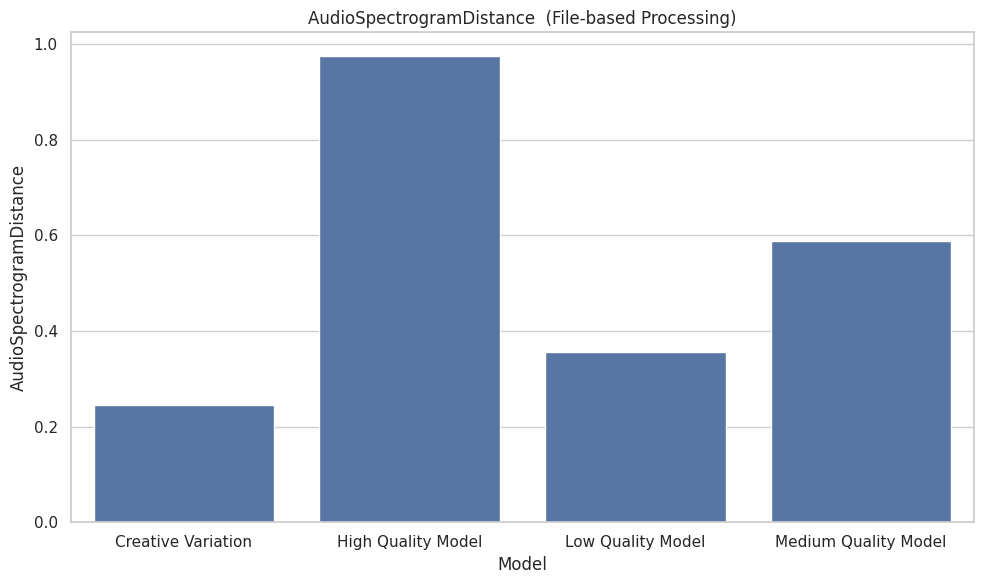


📊 File-based Evaluation Results:
metric_name           AudioSNR  AudioSpectrogramDistance
model_name                                              
Creative Variation       0.283                     0.244
High Quality Model       0.870                     0.976
Low Quality Model        0.283                     0.357
Medium Quality Model     0.282                     0.589

📂 Files processed:
  High Quality Model: high_quality_music.wav
  Medium Quality Model: medium_quality_music.wav
  Low Quality Model: low_quality_music.wav
  Creative Variation: creative_variation_music.wav
  Reference: reference_c_major.wav

💡 Key Insights from File-based Processing:
- Highest AudioSNR score: 0.870
- Highest AudioSpectrogramDistance score: 0.976
- Successfully processed 4 audio files
- GAICo automatically handled both WAV and MP3 formats

✅ File-based evaluation completed successfully!
Results shape: (8, 3)

🔄 Format Compatibility Demo
               Model Format  Exists  Size_KB
  High Quality Mod

In [22]:
# Demonstrate file-based evaluation with comprehensive results
print("📁 Audio files created in this session:")
print("-" * 50)

# List all created files (both WAV and MP3)
all_files = list(sample_dir.glob("*.wav")) + list(sample_dir.glob("*.mp3"))
for file in all_files[:10]:  # Show first 10
    print(f"  - {file.name}")

if len(all_files) > 10:
    print(f"  ... and {len(all_files) - 10} more files")

# Demonstrate file-based evaluation with detailed results
if len(music_samples) > 0:
    print("\n🎯 File-based Evaluation Demo")
    print("=" * 50)

    file_exp = Experiment(
        llm_responses=music_samples,  # These are already file paths
        reference_answer=music_ref_path,
    )

    file_results = file_exp.compare(
        metrics=["AudioSNR", "AudioSpectrogramDistance"],
        plot=True,  # Enable plot to show visual results
        plot_title_suffix=" (File-based Processing)",
    )

    if file_results is not None and not file_results.empty:
        print("\n📊 File-based Evaluation Results:")
        print("=" * 50)

        # Show results summary
        results_pivot = file_results.pivot(
            index="model_name", columns="metric_name", values="score"
        )
        print(results_pivot.round(3))

        # Show file paths being processed
        print("\n📂 Files processed:")
        for model, path in music_samples.items():
            print(f"  {model}: {Path(path).name}")
        print(f"  Reference: {Path(music_ref_path).name}")

        # Highlight key insights
        print("\n💡 Key Insights from File-based Processing:")
        best_snr = file_results.loc[file_results["metric_name"] == "AudioSNR", "score"].max()
        best_spec = file_results.loc[
            file_results["metric_name"] == "AudioSpectrogramDistance", "score"
        ].max()
        print(f"- Highest AudioSNR score: {best_snr:.3f}")
        print(f"- Highest AudioSpectrogramDistance score: {best_spec:.3f}")
        print(f"- Successfully processed {len(music_samples)} audio files")
        print("- GAICo automatically handled both WAV and MP3 formats")

        print("\n✅ File-based evaluation completed successfully!")
        print(f"Results shape: {file_results.shape}")
    else:
        print("⚠️ No results generated from file-based evaluation")

# Additional demonstration: Compare different file formats
print("\n🔄 Format Compatibility Demo")
print("=" * 30)

# Show that GAICo handles different formats seamlessly
format_info = []
for name, path in music_samples.items():
    file_path = Path(path)
    format_info.append(
        {
            "Model": name,
            "Format": file_path.suffix.upper(),
            "Exists": file_path.exists(),
            "Size_KB": round(file_path.stat().st_size / 1024, 1) if file_path.exists() else 0,
        }
    )

format_df = pd.DataFrame(format_info)
print(format_df.to_string(index=False))

print("\n📝 Note: GAICo seamlessly handles multiple audio formats:")
print("- WAV files (uncompressed, high quality)")
print("- MP3 files (compressed, widely supported)")
print("- Automatic format detection and processing")

## 🎯 Key Takeaways

### What We Learned:

1. **Audio needs specialized metrics** - Text similarity doesn't capture audio properties
2. **Two complementary metrics**:
   - **AudioSNR**: Overall quality and clarity
   - **AudioSpectrogramDistance**: Frequency/tonal similarity
3. **Easy integration** - Works seamlessly with GAICo's Experiment class
4. **Flexible input** - Supports numpy arrays and file paths

### Real-World Applications:

- **TTS Evaluation**: Compare outputs from ElevenLabs, Google Cloud TTS, Amazon Polly
- **Music Generation**: Evaluate MusicGen, AudioCraft, Riffusion outputs
- **Voice Cloning**: Assess quality of voice synthesis models
- **Audio Enhancement**: Compare denoising or upsampling algorithms

### Next Steps:

1. Try with your own AI-generated audio
2. Experiment with different threshold values
3. Combine with other GAICo metrics for multi-modal evaluation

### Resources:

- [GAICo Documentation](https://ai4society.github.io/projects/GenAIResultsComparator)
- [Common Voice Dataset](https://commonvoice.mozilla.org/)
- [LibriSpeech Dataset](https://www.openslr.org/12)
- [Free TTS APIs: gTTS, Edge-TTS]
